In [34]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns

Bivariate: 
1. Numeric to numeric: Correlation
2. Numeric to categorical: One-way ANOVA (3+ groups) or t-test (2 groups)
3. Categorical to categorical: Chi square

In [3]:
df = pd.read_csv("data/insurance.csv")

Step 1. Use the unique() func. to generate a list of the unique values in this categorical column

Step 2. Use the groupby() func. to sort the DataFrame by the current categorical column

Step 3. Make an empty list that will be a two-dimensional list of lists to store the label values associated with each category

Step 4. Loop through the unique category values

Step 5. Use the get_group() func. to return a list containing only the records for each unique value

Step 6. Use the append() func. to store the list of label values made in the prior step into our list-of-lists

In [31]:
def anova(df, feature, label):
    # Determine what the feature and label is. 
    
    groups = df[feature].unique() 
    
    df_grouped = df.groupby(feature) 
    
    group_labels = [] 
    
    for g in groups:
        g_list = df_grouped.get_group(g)
        
        group_labels.append(g_list[label])
        
    return stats.f_oneway(*group_labels)

In [32]:
def bivstats(df, label):
    # Make an empty DataFrame to store the results
    output_df = pd.DataFrame(columns=["r", "F", "Chi2", "p-value"])
    
    for col in df: # Use this to loop through the insurance DataFrame
        if not col == label:
            if df[col].isnull().sum() == 0:
                if pd.api.types.is_numeric_dtype(df[col]): # Only calculate from the numeric columns
                    r, p = stats.pearsonr(df[label], df[col])
                    output_df.loc[col] = [round(r, 4), np.nan, np.nan, round(p, 4)]
                else:
                    F, p = anova(df[[col, label]], col, label)
                    output_df.loc[col] = [np.nan, round(F, 4), np.nan, round(p, 4)]
            else:
                output_df.loc[col] = [np.nan, np.nan, np.nan, np.nan]
            
    return output_df.sort_values(by=["r"], ascending=False)

In [33]:
df = pd.read_csv("data/train.csv")
df.dropna(axis=1, inplace=True)
bivstats(df, "SalePrice")

,r,F,Chi2,p-value
OverallQual,0.7910,NaN,NaN,0.0000
GrLivArea,0.7086,NaN,NaN,0.0000
GarageCars,0.6404,NaN,NaN,0.0000
GarageArea,0.6234,NaN,NaN,0.0000
TotalBsmtSF,0.6136,NaN,NaN,0.0000
...,...,...,...,...
KitchenQual,NaN,407.8064,NaN,0.0000
Functional,NaN,4.0579,NaN,0.0005
PavedDrive,NaN,42.0242,NaN,0.0000
SaleType,NaN,28.8631,NaN,0.0000


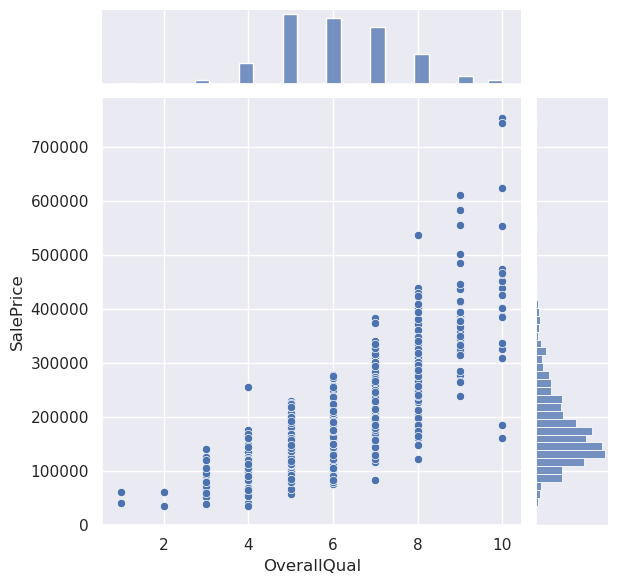

In [36]:
def scatter(feature, label):
    sns.set(color_codes=True)
    sns.jointplot(data=df, x=feature, y=label)
    
scatter(df.OverallQual, df.SalePrice)